In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [17]:
DATA_PATH = Path("../data/raw/Gaming and Mental Health.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [18]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1000, 27)

Columns:
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   str    
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   str    
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   str    
 5   primary_game                      1000 non-null   str    
 6   gaming_platform                   1000 non-null   str    
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   str    
 9   sleep_disruption_frequency        1000 non-null   str    
 10  academic_work_performance         1000 non-null   str    
 11  grades_gpa                        754 non-null    float64
 12  work_productivity_

In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1000,1000,GD0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.475,4.116105,13.0,18.0,20.0,22.0,35.0
gender,1000,3,Male,647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_gaming_hours,1000.0,NaN,NaN,NaN,6.1514,2.867194,0.5,4.1,6.0,8.025,15.1
game_genre,1000,7,MOBA,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_game,1000,24,Dota 2,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gaming_platform,1000,4,Mobile,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,1000.0,NaN,NaN,NaN,5.7381,1.441213,3.0,4.8,5.7,6.6,9.0
sleep_quality,1000,5,Fair,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_disruption_frequency,1000,5,Often,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df.head()

C:\Users\Boris\AppData\Local\Temp\ipykernel_20020\103085383.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [22]:
# target_col = "gaming_addiction_risk_level"
target_col = "grades_gpa"

print("Unique target values:")
print(df[target_col].unique())

Unique target values:
[1.25 3.75  nan 1.62 2.44 3.81 1.82 2.43 1.13 3.04 3.15 3.25 2.54 1.64
 1.89 2.76 2.14 2.91 1.12 3.27 2.63 1.94 3.41 3.91 3.71 2.31 1.21 3.02
 3.39 3.03 3.98 1.15 3.54 2.7  1.22 1.38 3.22 2.21 2.25 2.88 1.19 2.11
 3.87 1.39 2.02 2.3  1.41 2.08 2.   3.09 1.4  3.51 3.05 3.1  1.55 1.87
 1.01 2.48 1.17 2.32 1.98 3.56 1.42 2.95 2.4  1.29 3.06 2.46 3.21 1.5
 3.26 3.53 3.92 2.05 2.66 2.53 1.08 3.66 1.37 2.96 2.85 3.82 2.98 2.57
 2.6  1.32 1.75 2.86 1.1  1.96 2.19 1.11 1.69 3.31 1.74 3.11 1.03 4.
 2.1  3.59 3.47 1.91 1.78 1.85 3.37 2.58 1.34 2.73 1.76 1.43 1.61 3.34
 1.06 3.29 1.45 3.55 3.72 3.14 3.97 2.72 1.44 2.92 3.84 2.27 2.15 3.52
 1.23 3.23 3.5  1.24 2.84 1.77 2.41 1.3  1.31 1.07 3.44 3.69 1.28 3.2
 3.7  3.24 3.65 1.35 3.38 3.01 3.88 2.45 2.89 2.47 1.97 2.37 2.35 2.62
 3.74 2.33 3.28 1.05 3.07 1.53 1.6  2.69 1.18 2.18 1.14 2.01 3.99 1.09
 2.74 3.9  2.36 2.94 2.61 3.16 3.45 1.73 3.78 1.48 2.24 1.8  3.68 1.71
 3.36 1.47 3.3  2.59 3.48 2.5  3.19 1.49 3.49 2.09 2.22 3.7

In [23]:
target_counts = df[target_col].value_counts().sort_index()
target_counts

grades_gpa
1.01    1
1.02    2
1.03    5
1.04    1
1.05    3
       ..
3.96    1
3.97    3
3.98    6
3.99    2
4.00    1
Name: count, Length: 275, dtype: int64

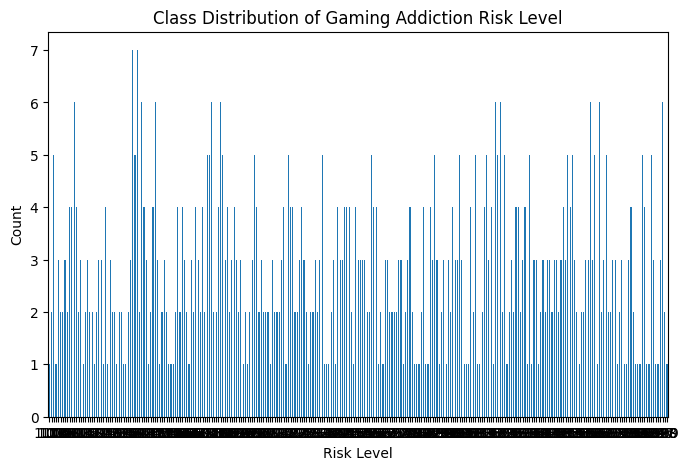

In [24]:
target_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution of Gaming Addiction Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values per column:")
missing

Missing values per column:


work_productivity_score    326
grades_gpa                 246
dtype: int64

In [26]:
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]

print("Missing percentage per column:")
missing_ratio

Missing percentage per column:


work_productivity_score    32.6
grades_gpa                 24.6
dtype: float64